# Лабораторная работа №5  
#### 1. Построение функций f(x) и g(x) на одном графике

Мы рассматриваем две функции:  

- **f(x) = sin(x²)**  
- **g(x) = ln|x|**  

Для построения графика используем библиотеку matplotlib.
1. Сначала создаём массив X от -4 до 4 (100 точек).  
2. Вычисляем значения функций f(x) и g(x).  
3. Строим первую функцию f(x) на основной оси Y (слева).  
 Линия красная, маркеры квадратные (s) и закрашены синим.  
4. Для второй функции g(x) создаём отдельную ось Y справа с помощью twinx().  
   Это позволяет строить две функции с разными масштабами значений.  
   Если бы использовали одну ось Y, синус «схлопнулся» бы, так как ln|x| имеет другой порядок значений.  
5. Настраиваем ось X (фиксируем значения [-4, -2, 0, 2, 4]).  
6. Добавляем заголовок графика. 

Text(0.5, 1.0, 'f(x) и g(x) - 100 точек')

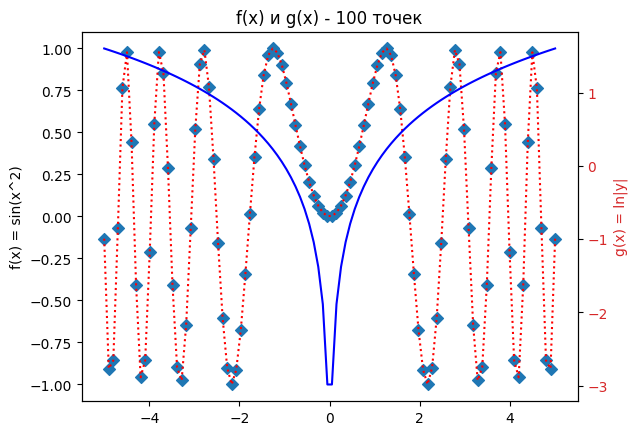

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(-5, 5, 100)
f_x = np.sin(x**2)
g_x = np.log(np.abs(x))
fig, ax = plt.subplots()
ax.plot(x,f_x, color = "red", linestyle=':')
ax.scatter(x,f_x, marker="D")
ax.set_ylabel('f(x) = sin(x^2)')
ax1 = ax.twinx()
color = 'tab:red'
ax1.plot(x,g_x, color ='blue')
ax1.set_ylabel('g(x) = ln|x|', color = color)
ax1.tick_params(axis='y', labelcolor=color)
# ax.set_xticks([-4, -2, 0, 2, 4])
plt.title("f(x) и g(x) - 100 точек")



#### 2. Визуализация функции 

В данной задаче мы построили несколько графиков в едином макете (subplot_mosaic):

- **Область A (центральный график):**  
  Контурный график функции z = sin(x² + ln(|y|)) для X, Y ∈ [-4, 4].  
  Добавлены координатные оси: красная горизонтальная (y=0) и зелёная вертикальная (x=0).  

- **Область B:**  
  Сечение функции по x=0 → z(y) = sin(ln|y|).  
  По оси X отложено значение функции, по оси Y — аргумент y.  

- **Область C:**  
  Сечение функции по y=0 → z(x) = sin(x²).  
  Видна характерная колебательная форма функции синуса.  

- **Область D:**  
  Вставлено изображение («Sherlock») с помощью imshow.  
  Для эстетики убраны оси (axis('off')).   

C:\Users\Админ\AppData\Local\Temp\ipykernel_8184\1346458573.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


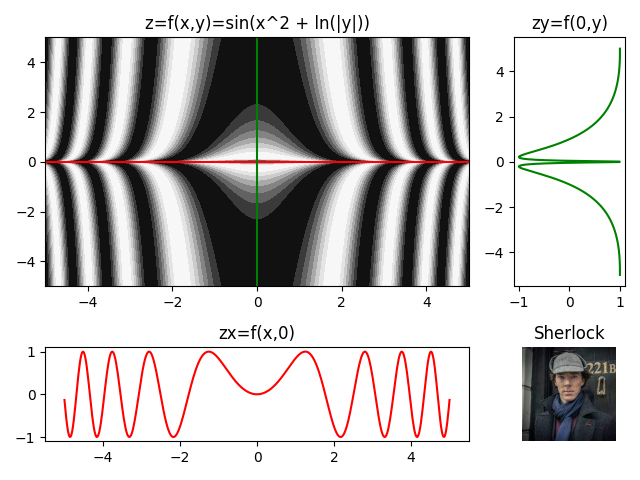

In [11]:
from matplotlib import image as mpimg
x = np.linspace(-5,5,500)
y = np.linspace(-5,5,500)
X,Y =np.meshgrid(x,y)
Z = np.sin(X**2 + np.log(np.abs(Y)))
fig, axs = plt.subplot_mosaic(
  '''
  AAAB
  AAAB
  CCCD
  ''',
  constrained_layout=True 
  )
im = axs['A'].contourf(X,Y,Z, cmap="Grays")
axs['A'].axhline(0, c='red')
axs['A'].axvline(0, c='green')
axs['A'].set_title('z=f(x,y)=sin(x^2 + ln(|y|))')

axs['B'].plot(np.sin(np.log(np.abs(y)+0)), y, color="green")
axs['B'].set_title('zy=f(0,y)')

axs['C'].plot(x,np.sin(x**2),color = 'red')
axs['C'].set_title('zx=f(x,0)')

img = mpimg.imread('images.jpeg')
axs['D'].imshow(img)
axs['D'].axis('off')
axs['D'].set_title('Sherlock')

plt.tight_layout()

#### 3. Круговая диаграмма «3 пути»

Мы построили круговую диаграмму (pie chart) по трём категориям:

- **Водка — 10**  
- **IT — 2**  
- **Рейвы — 5**

Особенности графика:
- Аргумент explode=[0, 0.3, 0] позволяет выделить сектор «IT», сместив его от центра.  
- Параметр startangle=90 поворачивает диаграмму так, чтобы начало отсчёта было сверху.  
- autopct="%.1f%%" выводит значения в процентах прямо на секторах.  
- Добавлен заголовок «3 Пути».  

#### Столбчатая диаграмма «2 Врага»

Построен комбинированный график для сравнения двух категорий:  

- **Чернослив — 832**  
- **Курага — 168**

Элементы графика:  
- Столбцы (bar) показывают абсолютные значения.  
- Над каждым столбцом добавлена подпись с числом.  
- Поверх столбцов проведена пунктирная красная линия (plot), которая соединяет значения.  
- Горизонтальная зелёная линия (axhline) показывает среднее значение (≈ 500).  
- На оси X установлены подписи категорий: «Чернослив» и «Курага».  
- Добавлена легенда и заголовок «2 Врага».  


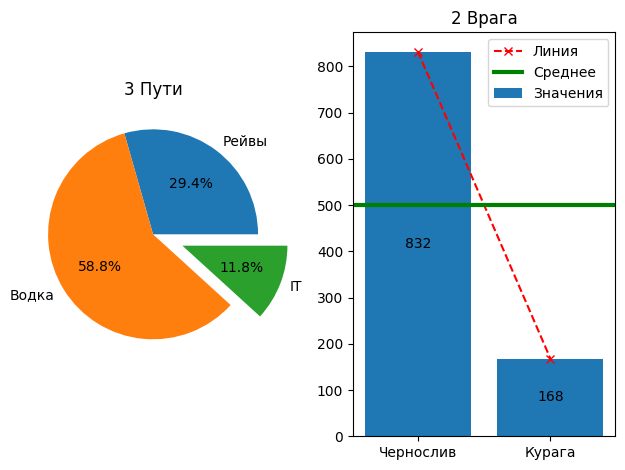

In [8]:
data = [5, 10, 2]
explode = [0,0,0.3]
labels = ['Рейвы', 'Водка', 'IT']

fig, ax = plt.subplots(1,2)

ax[0].pie(data, labels=labels, explode=explode, autopct="%.1f%%")
ax[0].set_title('3 Пути')

x = [0, 1]
data = [832, 168]
labels = ['Чернослив', 'Курага']

bar = ax[1].bar(x, data, label ='Значения')
plt.bar_label(bar, label_type='center')

ax[1].plot(x, data, marker='x', linestyle='--', color='red', label ='Линия')

mn = np.mean(data)
ax[1].axhline(mn,color='green', label='Среднее', linewidth = 3)

ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)

ax[1].set_title("2 Врага")
ax[1].legend(loc="upper right")

plt.tight_layout()


#### 4. 3D-график функции

Мы построили трёхмерную поверхность для функции.
Особенности графика:
- Поверхность построена с помощью plot_surface и окрашена по цветовой карте viridis.  
- Выделена конкретная точка **(-5, 5)** с её значением:  
  f(-5, 5) = 50 (показана красным маркером).  
- Добавлена подпись к точке с помощью ax.text.  
- Подписаны оси X, Y, Z, установлен заголовок.  

Text(0.5, 0, 'Z')

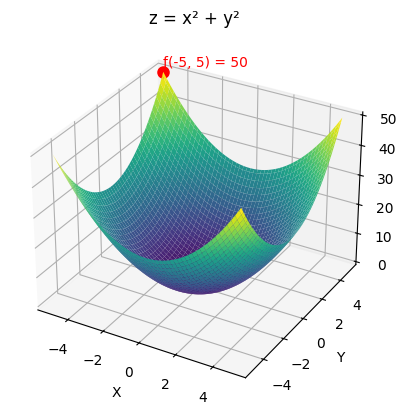

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')
x0, y0 = -5, 5
z0 = x0**2 + y0**2
ax.plot([x0], [y0], [z0], marker="o", color="red", markersize=8)
ax.text(x0, y0, z0 + 2, f"f({x0}, {y0}) = {z0}", color='red')

ax.set_title("z = x² + y²")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")


#### 5. Анимация каналов изображения

В этом примере реализована анимация разложения изображения на отдельные каналы.  

- В ячейке A выводится оригинальное изображение (Sherlock).  
- Жёлтая горизонтальная линия показывает текущую строку, которая анализируется.  
- В ячейках B, C, D, E строятся графики интенсивностей пикселей:  
  - R-канал (красный)  
  - B-канал (синий)  
  - G-канал (зелёный)  
  - α-канал (прозрачность)  
- Использован subplot_mosaic для организации расположения графиков. Функция update() на каждом кадре берёт строку пикселей и строит значения каналов. FuncAnimation из matplotlib.animation обеспечивает пошаговое обновление графика.  
 

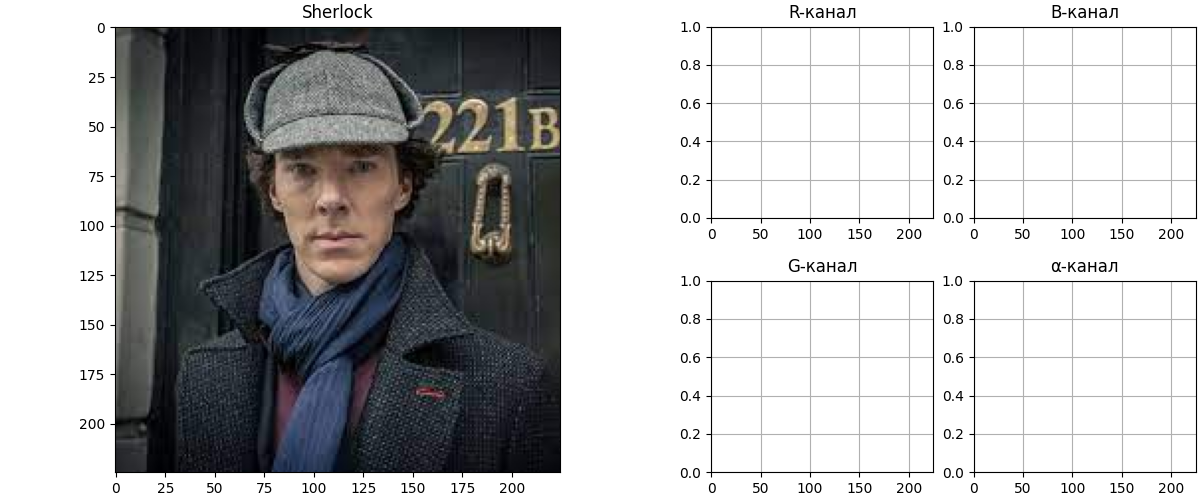

In [9]:
%matplotlib widget
import matplotlib.animation as animation
from PIL import Image

img = np.array(Image.open("images.jpeg").convert("RGBA"))
height, width = img.shape[:2]

fig, axs = plt.subplot_mosaic(
    '''
    AAABC
    AAADE
    ''',
    figsize=(12,5),
    constrained_layout=True
)

ax_img = axs['A']
ax_img.imshow(img)
line = ax_img.axhline(0, color ='yellow')
ax_img.set_title('Sherlock')

ax_r = axs['B']
ax_b = axs['C']
ax_g = axs['D']
ax_a = axs['E']

r_line, = ax_r.plot([], [], 'r')
b_line, = ax_b.plot([], [], 'b')
g_line, = ax_g.plot([], [], 'g')
a_line, = ax_a.plot([], [], 'k', alpha=0.5)

for ax, title in zip([ax_r, ax_b, ax_g, ax_a],
                     ['R-канал','B-канал','G-канал','α-канал']):
    ax.set_xlim(0, width)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(True)

def update(frame):
    line.set_ydata([frame, frame])
    row = img[frame] / 255.0

    r_line.set_data(np.arange(width), row[:,0])  
    b_line.set_data(np.arange(width), row[:,1])  
    g_line.set_data(np.arange(width), row[:,2])  
    a_line.set_data(np.arange(width), row[:,3]) 

    return r_line, g_line, b_line, a_line, line

ani = animation.FuncAnimation(fig, update, frames=height, interval=50)